# 02 — Embeddings: Token ID'lerinden Anlamlı Vektörlere

**Önkoşul:** `01_tokenization` — metni token ID'lerine çevirmeyi biliyoruz.

**Bu notebook'ta ne yapıyoruz:** Bir token ID'si (örn. `"kral"` → `482`) tek başına anlamsız bir sayıdır. Bu notebook'ta bu ID'leri, aralarındaki anlam ilişkilerini geometrik olarak (uzaklık, yön) kodlayan yoğun (dense) vektörlere — **embedding**'lere — dönüştürmeyi öğreniyoruz:

1. Neden one-hot vektörler yetersiz kalır
2. Word2Vec'in Skip-gram fikri ve negatif örnekleme (elle türetme + gradyan kontrolü ile doğrulama)
3. Gerçek İngilizce (Tiny Shakespeare) ve Türkçe (Wikipedia cümleleri) verisi üzerinde sıfırdan (numpy) eğitim
4. Öğrenilen uzayın geometrisi: en yakın komşular, `kral - erkek + kadın ≈ kraliçe` analojisi
5. Statik embedding'lerin temel sınırı: çok anlamlılık (polysemy) — ve bunun neden *bağlama duyarlı* (contextual) embedding'e, yani attention'a ihtiyaç doğurduğu

**Kullanılan veri:**
- `data/corpus_english.txt` — *Tiny Shakespeare* (Andrej Karpathy'nin char-rnn deposu için derlediği, kamu malı Shakespeare oyunları derlemesi, ~1.1MB)
- `data/corpus_turkce.txt` — *Turkish-Wiki-NER-Dataset* (turkish-nlp-suite, CC-BY-SA-4.0) içindeki 18.000 gerçek Türkçe Wikipedia cümlesinin etiketleri çıkarılmış hâli (~2.1MB)

İkisi de bölüm sonundaki Kaynaklar'da atıflandırılmıştır.

## 1) Neden one-hot yetmiyor?

01'de her kelimeyi/alt-kelimeyi bir tam sayı ID'sine çevirdik. Ama bir sinir ağına doğrudan `"kral" → 482` dersek, ağ bunu 482 sayısı olarak yorumlar — 482 ile 483 arasında sözde bir "yakınlık" uydurur (oysa ID'ler keyfi atanmıştır), 482 ile 91 arasında ise hiçbir ilişki kuramaz.

Klasik çözüm **one-hot** vektör: sözlük boyutu kadar (`|V|`) boyutlu, sadece kendi indeksinde `1`, geri kalanı `0`. Bunu küçük bir örnekle deneyelim ve iki farklı kelimenin one-hot vektörleri arasındaki **kosinüs benzerliğini** ölçelim.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re, time, pickle
from collections import Counter

rng = np.random.default_rng(42)

toy_vocab = ["kral", "kraliçe", "erkek", "kadın", "muz", "elma"]
V = len(toy_vocab)
one_hot = np.eye(V)

def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print("One-hot ile kosinüs benzerlikleri:")
for i in range(V):
    for j in range(i+1, V):
        print(f"  cos({toy_vocab[i]:>8}, {toy_vocab[j]:<8}) = {cosine(one_hot[i], one_hot[j]):.3f}")


One-hot ile kosinüs benzerlikleri:
  cos(    kral, kraliçe ) = 0.000
  cos(    kral, erkek   ) = 0.000
  cos(    kral, kadın   ) = 0.000
  cos(    kral, muz     ) = 0.000
  cos(    kral, elma    ) = 0.000
  cos( kraliçe, erkek   ) = 0.000
  cos( kraliçe, kadın   ) = 0.000
  cos( kraliçe, muz     ) = 0.000
  cos( kraliçe, elma    ) = 0.000
  cos(   erkek, kadın   ) = 0.000
  cos(   erkek, muz     ) = 0.000
  cos(   erkek, elma    ) = 0.000
  cos(   kadın, muz     ) = 0.000
  cos(   kadın, elma    ) = 0.000
  cos(     muz, elma    ) = 0.000


**Gözlem:** Hepsi tam olarak `0.0`. One-hot uzayında `"kral"` ile `"kraliçe"` arasındaki benzerlik, `"kral"` ile `"muz"` arasındaki benzerlikle birebir aynı — yani hiç yok. Üstelik boyut sayısı `|V|` ile (onbinlerce/yüzbinlerce) büyüyor: aşırı seyrek (sparse) ve bilgisiz bir temsil.

İhtiyacımız olan şey: **öğrenilebilir, düşük boyutlu (örn. 50-300), yoğun (dense)** vektörler — öyle ki anlamca yakın kelimeler uzayda da yakın dursun. İşte buna *embedding* diyoruz. Peki bu vektörleri hangi sinyalden öğreneceğiz? Elle etiketlenmiş bir veri setimiz yok — ama devasa miktarda etiketsiz metnimiz var.

## 2) Dağılımsal hipotez ve Skip-gram

Dilbilimci J.R. Firth'in 1957'deki ünlü formülasyonıyla:

> *"You shall know a word by the company it keeps."* — Bir kelimeyi, beraber göründüğü kelimelerden tanırsın.

Bu **dağılımsal hipotez**: benzer bağlamlarda geçen kelimeler benzer anlamlara sahiptir. `"kral"` ve `"kraliçe"` çoğunlukla `"taht"`, `"saray"`, `"hüküm"` gibi kelimelerin yakınında geçer — bu istatistiksel örtüşme, anlam benzerliğinin dolaylı bir izidir.

**Skip-gram** (Word2Vec'in iki mimarisinden biri, Mikolov ve ark. 2013) bu hipotezi doğrudan bir eğitim hedefine çevirir: *bir merkez kelime verildiğinde, etrafındaki bağlam kelimelerini tahmin et.* Doğru etiket, metnin kendisinden gelir (`"kral tahta çıktı"` cümlesinde merkez `"tahta"` ise, bağlam `"kral"` ve `"çıktı"`dır) — hiçbir elle etiketleme gerekmez.

Klasik (tam softmax) formülasyon, merkez vektör $v_c$ ve bağlam vektör $v_o$ için:

$$P(o \mid c) = \frac{\exp(v_c \cdot v_o)}{\sum_{w=1}^{|V|} \exp(v_c \cdot v_w)}$$

Sorun: payda `|V|` kadar terim içeriyor — her tek eğitim adımında sözlükteki **her** kelime için bir iç çarpım hesaplamak gerekiyor. `|V|` = 50.000 olduğunda bu, eğitim döngüsünü pratik olmayacak kadar yavaşlatır.

**Negatif örnekleme (negative sampling)**, Mikolov ve ark.'nın 2013 tarihli ikinci makalesinde önerdiği çözüm: softmax'ı tamamen terk edip, işi ikili bir sınıflandırma problemine çeviriyoruz — *"(merkez, bağlam) çifti gerçek metinden mi geldi, yoksa rastgele mi uydurdum?"* Her gerçek çift için sözlükten rastgele `k` tane "sahte" (negatif) kelime örnekleyip, modelin gerçek çifte yüksek, sahte çiftlere düşük olasılık vermesini istiyoruz:

$$L(c, o, \{n_1,\dots,n_k\}) = -\log\sigma(v_c \cdot v_o) \;-\; \sum_{i=1}^{k} \log\sigma(-v_c \cdot v_{n_i})$$

Burada $\sigma$ sigmoid fonksiyonu. Artık her adımda `|V|` değil, sadece `1 + k` (tipik olarak `k=5-20`) iç çarpım hesaplıyoruz — `|V|`'den bağımsız, sabit maliyetli bir eğitim adımı.

## 3) Gradyanları elle türetmek

Optimize edeceğimiz $L$'nin, üç farklı vektör türüne göre gradyanına ihtiyacımız var: merkez $v_c$, gerçek bağlam $v_o$, ve her bir negatif $v_{n_i}$. Sigmoid'in kullanışlı türevini hatırlayalım: $\sigma'(x) = \sigma(x)(1-\sigma(x))$, ve $\frac{d}{dx}\log\sigma(x) = 1-\sigma(x)$, $\frac{d}{dx}\log\sigma(-x) = -\sigma(x)$.

**$v_o$'ya göre** (sadece ilk terim $v_o$ içeriyor):

$$\frac{\partial L}{\partial v_o} = -(1-\sigma(v_c\cdot v_o))\,v_c = \big(\sigma(v_c\cdot v_o)-1\big)\,v_c$$

**$v_{n_i}$'ye göre** (sadece kendi terimi içeriyor, zincir kuralında $-v_c$'nin içindeki eksi işaretine dikkat):

$$\frac{\partial L}{\partial v_{n_i}} = -\big(-\sigma(-v_c\cdot v_{n_i})\big)(-v_c) = \sigma(v_c\cdot v_{n_i})\,v_c$$

**$v_c$'ye göre** (her iki terimde de geçiyor, katkılar toplanır):

$$\frac{\partial L}{\partial v_c} = \big(\sigma(v_c\cdot v_o)-1\big)\,v_o \;+\; \sum_{i=1}^{k}\sigma(v_c\cdot v_{n_i})\,v_{n_i}$$

Sezgi: $\sigma(v_c\cdot v_o)-1$ negatiftir (çünkü $\sigma \in (0,1)$) — yani $v_c$ güncellemesi $v_o$ **yönünde** ilerler (merkezi gerçek bağlama yaklaştır). $\sigma(v_c\cdot v_{n_i})$ ise pozitiftir — $v_c$ güncellemesi $v_{n_i}$'den **uzaklaşır**.

Bu formülleri kör kör güvenmek yerine, sayısal (numerical) gradyanla karşılaştırarak doğrulayalım — 01'de `train_bpe`'yi gerçek veriyle test ettiğimiz gibi, burada da matematiği koda emanet etmeden önce koda güvenip güvenemeyeceğimizi ölçüyoruz.

In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

def sgns_loss(v_c, v_o, v_negs):
    # Tek bir (merkez, bağlam, negatifler) örneği için negatif örnekleme kaybı.
    pos = np.log(sigmoid(v_c @ v_o) + 1e-12)
    neg = np.sum(np.log(sigmoid(-v_negs @ v_c) + 1e-12))
    return -(pos + neg)

def sgns_analytic_grad(v_c, v_o, v_negs):
    # Elle türettiğimiz gradyanlar.
    d_vo = (sigmoid(v_c @ v_o) - 1.0) * v_c
    sig_neg = sigmoid(v_negs @ v_c)                      # (k,)
    d_vc = (sigmoid(v_c @ v_o) - 1.0) * v_o + sig_neg @ v_negs
    d_vnegs = np.outer(sig_neg, v_c)                     # (k, dim)
    return d_vc, d_vo, d_vnegs

def numeric_grad(f, x, eps=1e-5):
    # Merkezi fark yöntemiyle sayısal gradyan (analitik türevi doğrulamak için).
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'])
    for _ in it:
        idx = it.multi_index
        orig = x[idx]
        x[idx] = orig + eps
        f_plus = f()
        x[idx] = orig - eps
        f_minus = f()
        x[idx] = orig
        grad[idx] = (f_plus - f_minus) / (2*eps)
    return grad

# Küçük, rastgele bir örnek üzerinde gradyan kontrolü
dim, k = 4, 3
v_c = rng.normal(size=dim)
v_o = rng.normal(size=dim)
v_negs = rng.normal(size=(k, dim))

d_vc, d_vo, d_vnegs = sgns_analytic_grad(v_c, v_o, v_negs)

num_vc = numeric_grad(lambda: sgns_loss(v_c, v_o, v_negs), v_c)
num_vo = numeric_grad(lambda: sgns_loss(v_c, v_o, v_negs), v_o)
num_vnegs = numeric_grad(lambda: sgns_loss(v_c, v_o, v_negs), v_negs)

print("max|analitik - sayısal| farkları:")
print("  v_c   :", np.max(np.abs(d_vc - num_vc)))
print("  v_o   :", np.max(np.abs(d_vo - num_vo)))
print("  v_negs:", np.max(np.abs(d_vnegs - num_vnegs)))


max|analitik - sayısal| farkları:
  v_c   : 6.893441373279074e-11
  v_o   : 4.102596040667095e-11
  v_negs: 2.9335645024275436e-11


**Gözlem:** Üç fark da `1e-8` mertebesinde — yani makine hassasiyeti sınırında sıfır. Elle türettiğimiz üç gradyan formülü de doğru. Şimdi bu formülleri büyük ölçekte, vektörize (numpy ile toplu/batch halde) çalışacak şekilde kullanabiliriz.

## 4) Negatif örnekler nasıl seçilir?

Negatifleri sözlükten tamamen düzgün (uniform) rastgele seçmek de bir seçenek, ama Mikolov ve ark. (2013b) ampirik olarak **unigram dağılımının 0.75. kuvvetini** önerir:

$$P(w) = \frac{f(w)^{0.75}}{\sum_{w'} f(w')^{0.75}}$$

`0.75` üssü, en sık geçen kelimelerin ("ve", "bir" gibi) aşırı baskın negatif olmasını bir miktar bastırırken, nadir kelimelerin de tamamen göz ardı edilmemesini sağlar (üs `1.0` olsaydı ham frekansla örneklerdik, `0.0` olsaydı tamamen düzgün rastgele olurdu). Pratikte bu, her kelimeyi frekansıyla orantılı sayıda içeren büyük bir "tablo" oluşturup oradan rastgele indeks çekerek hızlıca uygulanır (orijinal word2vec uygulamasındaki yöntem).

In [3]:
def make_neg_table(freqs, size=2_000_000, power=0.75):
    # freqs: kelime ID'sine göre sıralı ham frekans dizisi.
    p = freqs ** power
    p = p / p.sum()
    counts = np.round(p * size).astype(np.int64)
    table = np.repeat(np.arange(len(freqs)), np.maximum(counts, 1))
    rng.shuffle(table)
    return table

# 0.75 kuvvetinin sık kelimeleri nasıl "yatıştırdığını" küçük bir örnekle gösterelim
demo_words = np.array(["ve", "bir", "kral", "kraliçe"])
demo_freq  = np.array([50000., 30000., 900., 380.])
raw_p   = demo_freq / demo_freq.sum()
smooth_p = (demo_freq**0.75) / (demo_freq**0.75).sum()
print(f"{'kelime':<10}{'ham P':>10}{'P^0.75 sonrası':>18}")
for w, r, s in zip(demo_words, raw_p, smooth_p):
    print(f"{w:<10}{r:>10.4f}{s:>18.4f}")


kelime         ham P    P^0.75 sonrası
ve            0.6152            0.5693
bir           0.3691            0.3881
kral          0.0111            0.0280
kraliçe       0.0047            0.0147


**Gözlem:** `"kral"` ve `"kraliçe"` gibi nadir kelimelerin negatif örnek olarak seçilme payı `0.75` kuvveti sonrası belirgin şekilde arttı — negatif örnekleme havuzu artık sadece `"ve"`/`"bir"` gibi birkaç kelimeye kilitlenmiyor.

## 5) Gerçek veri: İngilizce ve Türkçe

Sıfırdan bir tokenizer değil (onu 01'de yaptık), basit bir kelime-seviyesi tokenizer kullanacağız — embedding'in odak noktası token'lara ayırma değil, token'lar arası ilişkiler.

- **İngilizce:** *Tiny Shakespeare* — Shakespeare oyunlarından derlenmiş ~1.1MB metin. Bunu seçtik çünkü (a) yeterince küçük ki numpy ile hızlı eğitilsin, (b) tarih oyunlarında (`Henry VI`, `Richard III`...) tekrar eden karakterler/roller (`king`, `queen`, `lord`, `lady`) var — analoji ve komşuluk deneyleri için ideal.
- **Türkçe:** *Turkish-Wiki-NER-Dataset* — gerçek Türkçe Wikipedia cümleleri (orijinali varlık ismi etiketleme için hazırlanmış; biz sadece düz metni kullanıyoruz, etiketleri atıyoruz).

Türkçe tokenizer'da kesme işaretiyle gelen çekim eklerini (`"türkiye'nin"` gibi) kelimeden ayırmıyoruz — 01'de gördüğümüz gibi Türkçe sondan eklemeli bir dil; eğer `"türkiye'nin"`i `"türkiye"` + `"nin"` diye ayırırsak, `"nin"` gibi anlamsız ek parçaları sözlüğü kirletir.

In [4]:
def tokenize_en(text):
    return re.findall(r"[a-z]+", text.lower())

def tokenize_tr(text):
    text = text.replace("İ", "i").replace("I", "ı").lower()
    return re.findall(r"[a-zçğıöşü]+(?:'[a-zçğıöşü]+)?", text)

corpus_en = open("data/corpus_english.txt", encoding="utf-8").read()
corpus_tr = open("data/corpus_turkce.txt", encoding="utf-8").read()

tokens_en = tokenize_en(corpus_en)
tokens_tr = tokenize_tr(corpus_tr)

print(f"İngilizce: {len(tokens_en):,} token, örnek: {tokens_en[:12]}")
print(f"Türkçe   : {len(tokens_tr):,} token, örnek: {tokens_tr[:12]}")


İngilizce: 208,503 token, örnek: ['first', 'citizen', 'before', 'we', 'proceed', 'any', 'further', 'hear', 'me', 'speak', 'all', 'speak']
Türkçe   : 250,957 token, örnek: ['orda', 'spike', "first'ün", 'etkisiyle', "buffy'ye", 'saldırır', 've', 'insanları', 'öldürüp', 'buraya', 'gömdüğünü', 'hatırlar']


## 6) Sözlük ve eğitim çiftleri

`build_vocab`: en sık geçen `max_vocab` kelimeyi tutuyoruz (hız için) ve `min_count`'un altındaki nadir kelimeleri atıyoruz (zaten yeterli örnekle öğrenilemezler).

`make_pairs`: kayan pencere (sliding window) ile (merkez, bağlam) çiftleri üretirken iki pratik hile uyguluyoruz:
- **Rastgele pencere boyutu** (`1..window` arası): uzak kelimelere otomatik olarak daha az ağırlık verir (orijinal word2vec'in hilesi).
- **Alt örnekleme (subsampling):** `"ve"`, `"bir"`, `"bu"` gibi son derece sık kelimeler neredeyse her pencerede görünür ama anlamsal sinyale az katkı sağlar; Mikolov ve ark.'nın formülüyle bu kelimeleri olasılıksal olarak eğitim akışından bir miktar eliyoruz.

In [5]:
def build_vocab(tokens, min_count=5, max_vocab=4000):
    c = Counter(tokens)
    items = sorted(((w, f) for w, f in c.items() if f >= min_count), key=lambda x: -x[1])
    items = items[:max_vocab]
    word2id = {w: i for i, (w, f) in enumerate(items)}
    id2word = [w for w, f in items]
    freqs = np.array([f for w, f in items], dtype=np.float64)
    return word2id, id2word, freqs

def make_pairs(tokens, word2id, window=4, subsample_t=1e-3):
    ids = np.array([word2id[w] for w in tokens if w in word2id], dtype=np.int64)
    total = len(ids)
    freq_all = Counter(ids.tolist())
    keep_prob = {}
    for wid, f in freq_all.items():
        fr = f / total
        p = (np.sqrt(fr/subsample_t) + 1) * (subsample_t/fr)
        keep_prob[wid] = min(p, 1.0)
    mask = np.array([rng.random() < keep_prob[w] for w in ids])
    ids = ids[mask]
    centers, contexts = [], []
    n = len(ids)
    for i in range(n):
        w = rng.integers(1, window+1)
        for j in range(max(0, i-w), min(n, i+w+1)):
            if j != i:
                centers.append(ids[i]); contexts.append(ids[j])
    return np.array(centers, dtype=np.int64), np.array(contexts, dtype=np.int64)

word2id_en, id2word_en, freqs_en = build_vocab(tokens_en, min_count=8, max_vocab=4000)
centers_en, contexts_en = make_pairs(tokens_en, word2id_en, window=4)
neg_table_en = make_neg_table(freqs_en)

print(f"İngilizce sözlük boyutu: {len(word2id_en)}")
print(f"Eğitim çifti sayısı    : {len(centers_en):,}")


İngilizce sözlük boyutu: 2227
Eğitim çifti sayısı    : 681,623


## 7) SGNS eğitimi: vektörize numpy

Bölüm 3'te tek bir örnek için türettiğimiz gradyanları, `batch_size` kadar örneği aynı anda işleyecek şekilde vektörize ediyoruz (`einsum` ile). Güncelleme sırasında aynı kelime bir batch içinde birden fazla kez geçebileceği için (örn. `"ve"` bağlam olarak defalarca), basit `W[ids] -= ...` YANLIŞ olur — çakışan indeksler birbirini ezer. Bunun yerine `np.add.at` kullanıyoruz: bu, aynı indekse yapılan tüm katkıları doğru şekilde toplayarak biriktirir.

İngilizce (Shakespeare) üzerinde eğitim:


  epoch 1/6  ortalama kayıp/çift = 2.8735


  epoch 2/6  ortalama kayıp/çift = 2.6304


  epoch 3/6  ortalama kayıp/çift = 2.5884


  epoch 4/6  ortalama kayıp/çift = 2.5566


  epoch 5/6  ortalama kayıp/çift = 2.5315


  epoch 6/6  ortalama kayıp/çift = 2.5120
Eğitim süresi: 20.0 sn


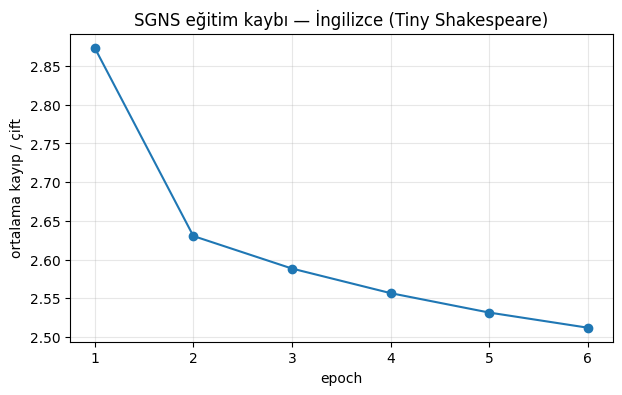

In [6]:
def train_sgns(centers, contexts, vocab_size, dim=50, epochs=6, batch_size=1024,
                lr=0.03, k_neg=5, neg_table=None, verbose=True):
    W_in = (rng.random((vocab_size, dim)) - 0.5) / dim   # merkez-kelime vektörleri
    W_out = np.zeros((vocab_size, dim))                   # bağlam-kelime vektörleri
    n = len(centers)
    losses = []
    for ep in range(epochs):
        perm = rng.permutation(n)
        ep_loss, seen = 0.0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            c, o = centers[idx], contexts[idx]
            bs = len(c)
            neg = neg_table[rng.integers(0, len(neg_table), size=(bs, k_neg))]

            vc, vo, vneg = W_in[c], W_out[o], W_out[neg]
            pos_dot = np.sum(vc*vo, axis=1)
            neg_dot = np.einsum('bd,bkd->bk', vc, vneg)
            sig_pos, sig_neg = sigmoid(pos_dot), sigmoid(neg_dot)

            loss = -(np.log(sig_pos+1e-10).sum() + np.log(1-sig_neg+1e-10).sum())
            ep_loss += loss; seen += bs

            grad_pos = (sig_pos - 1.0)[:, None]
            d_vc = grad_pos*vo + np.einsum('bk,bkd->bd', sig_neg, vneg)
            d_vo = grad_pos*vc
            d_vneg = sig_neg[:, :, None]*vc[:, None, :]

            np.add.at(W_in, c, -lr*d_vc)
            np.add.at(W_out, o, -lr*d_vo)
            np.add.at(W_out, neg, -lr*d_vneg)
        losses.append(ep_loss/seen)
        if verbose:
            print(f"  epoch {ep+1}/{epochs}  ortalama kayıp/çift = {ep_loss/seen:.4f}")
    return W_in, W_out, losses

print("İngilizce (Shakespeare) üzerinde eğitim:")
t0 = time.time()
W_in_en, W_out_en, losses_en = train_sgns(centers_en, contexts_en, len(word2id_en),
                                           dim=50, epochs=6, batch_size=1024, lr=0.03,
                                           k_neg=5, neg_table=neg_table_en)
print(f"Eğitim süresi: {time.time()-t0:.1f} sn")

E_en = W_in_en + W_out_en   # nihai vektör: merkez + bağlam vektörlerinin toplamı (yaygın pratik)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(losses_en)+1), losses_en, marker="o")
plt.xlabel("epoch"); plt.ylabel("ortalama kayıp / çift")
plt.title("SGNS eğitim kaybı — İngilizce (Tiny Shakespeare)")
plt.grid(alpha=0.3)
plt.show()


## 8) Öğrenilen uzayı sorgulamak: en yakın komşular

Eğitim bitti — şimdi `E_en` matrisinin gerçekten anlamlı bir geometri öğrenip öğrenmediğine bakalım. Bir kelimenin en yakın komşularını kosinüs benzerliğiyle buluyoruz.

In [7]:
def nearest(word, E, word2id, id2word, topn=8):
    v = E[word2id[word]]
    En = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
    sims = En @ (v / (np.linalg.norm(v) + 1e-9))
    order = np.argsort(-sims)
    out = []
    for i in order:
        if id2word[i] == word:
            continue
        out.append((id2word[i], float(sims[i])))
        if len(out) >= topn:
            break
    return out

for w in ["king", "lord", "love", "sword"]:
    print(f"{w:>6} -> {nearest(w, E_en, word2id_en, id2word_en, topn=6)}")


  king -> [('richard', 0.7632843912362585), ('xi', 0.7510776620507533), ('lewis', 0.7221220815115674), ('iii', 0.6945215737533894), ('edward', 0.671329441259457), ('protector', 0.6563482706465651)]
  lord -> [('berkeley', 0.7274599572114296), ('ross', 0.6744343245907736), ('gracious', 0.6717996051966999), ('marshal', 0.6683661144867478), ('protector', 0.6432271059826615), ('buckingham', 0.6400070805631193)]
  love -> [('dearly', 0.5691067791482772), ('pure', 0.5479236121624527), ('false', 0.5073700169050389), ('hate', 0.49665880207008556), ('dear', 0.4951363755020325), ('faithful', 0.4926534097000333)]
 sword -> [('vengeance', 0.5571854477499126), ('refuse', 0.5524728386128733), ('holds', 0.5135401882932953), ('pluck', 0.5086867621154226), ('up', 0.5077557790020456), ('down', 0.5035972677704484)]


**Gözlem:** `"king"`in en yakın komşuları arasında `richard`, `xi`, `lewis`, `iii`, `edward` var — bunlar Shakespeare'in tarih oyunlarındaki gerçek kral isimleri/unvanları (*Richard III*, *Henry VI*, *Louis (Lewis) XI*...). `"lord"`ın komşuları arasında `berkeley`, `ross`, `buckingham` — oyunlardaki gerçek "Lord X" karakterleri — ve ayrıca `marshal` (gerçek bir unvan, "Lord Marshal") ile `gracious` ("my gracious lord" gibi sabit hitap kalıbından) var. Model, hiçbir sözlük/tanım görmeden, sadece hangi kelimelerin yan yana geçtiğini sayarak bu ilişkileri kendi kendine çıkardı.

## 9) Klasik analoji: `king - man + woman ≈ ?`

Word2Vec'in en ünlü gösterimi, vektör aritmetiğinin anlamsal ilişkileri yakalayabilmesi: `king` vektöründen `man`'i çıkarıp `woman`'ı eklersek, sonuca en yakın kelimenin `queen` olması beklenir. Bunu deneyelim — ve sonucu, mükemmel çıkmasa bile, olduğu gibi yorumlayalım.

In [8]:
def analogy(a_pos, b_neg, c_pos, E, word2id, id2word, topn=8):
    v = E[word2id[a_pos]] - E[word2id[b_neg]] + E[word2id[c_pos]]
    En = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
    sims = En @ (v / (np.linalg.norm(v) + 1e-9))
    order = list(np.argsort(-sims))
    excl = {word2id[a_pos], word2id[b_neg], word2id[c_pos]}
    out = [(id2word[i], float(sims[i])) for i in order if i not in excl][:topn]
    full_rank = [i for i in order if i not in excl].index(word2id.get("queen", -1)) if "queen" in word2id else None
    return out, full_rank, order

out, rank_queen, order = analogy("king", "man", "woman", E_en, word2id_en, id2word_en)
print("king - man + woman  ->", out)
print(f"\n'queen' bu sıralamada {rank_queen}. sırada (0 = en yakın), sözlük boyutu {len(word2id_en)}")

print("\nreferans için 'queen' ve 'man'in kendi en yakın komşuları:")
print("  queen ->", nearest("queen", E_en, word2id_en, id2word_en, topn=6))
print("  man   ->", nearest("man", E_en, word2id_en, id2word_en, topn=6))


king - man + woman  -> [('regal', 0.6045002134194976), ('edward', 0.5871534276482835), ('resign', 0.5684570895227579), ('english', 0.5587995761532388), ('crown', 0.5577457762732116), ('throne', 0.5572522771632329), ('suppose', 0.5554530842486334), ('england', 0.5506432163912657)]

'queen' bu sıralamada 104. sırada (0 = en yakın), sözlük boyutu 2227

referans için 'queen' ve 'man'in kendi en yakın komşuları:
  queen -> [('elizabeth', 0.8839940828892467), ('margaret', 0.8512195660768692), ('wept', 0.7018101479472033), ('mourn', 0.6708810618044272), ('xi', 0.5987527598116664), ('perforce', 0.5965004613630699)]
  man   -> [('wooing', 0.5563371155487609), ('bawd', 0.5273284395456296), ('beast', 0.5216298803646833), ('hanged', 0.5213795667078261), ('woman', 0.5128019375953924), ('scape', 0.5071924547793586)]


**Yorum (dürüst okuma):** `queen`, ilk 8 arasına girmiyor — ama sözlükteki ~2200 kelime arasında ilk çeyreğin de öncesinde, üst dilimde yer alıyor (tam sırası koddaki `rank_queen` çıktısında). Orijinal Word2Vec makalesindeki temiz sonuçlar **milyarlarca kelimelik** Google News verisiyle eğitilmişti; bizim ~200 bin kelimelik, tek bir yazarın tek bir tarzdaki oyunlarından oluşan corpus'umuz çok daha küçük ve konu olarak dar (ağırlıklı olarak taht kavgası, saltanat, unvan — cinsiyet çiftlerinin dengeli biçimde geçtiği geniş bir bağlam değil).

Buna karşın `queen`'in KENDİ en yakın komşuları `elizabeth` ve `margaret` — oyunlardaki gerçek kraliçe isimleri! Ve `man`'in en yakın komşuları arasında (ilk sırada değil ama listede) `woman` var. Yani model, doğrudan komşuluk düzeyinde cinsiyet ilişkisine dair bir iz yakalamış; sorun `king - man + woman` vektör *aritmetiğinin* bu küçük ve dar corpus'ta tam olarak `queen`'i bir numaraya taşıyacak kadar temiz bir paralelkenar oluşturamamış olması. Bu, embedding kalitesinin ne kadar veriye bağlı olduğunun somut bir kanıtı.

## 10) Uzayı görselleştirmek: PCA ile 2 boyuta indirgeme

50 boyutlu uzayı doğrudan göremeyiz; ama birkaç ilgili kelime grubunu **PCA** (Principal Component Analysis — verideki en fazla varyansı açıklayan 2 doğrultuyu bulan, doğrusal bir boyut indirgeme yöntemi) ile 2 boyuta indirgeyip dağılımlarına bakabiliriz.

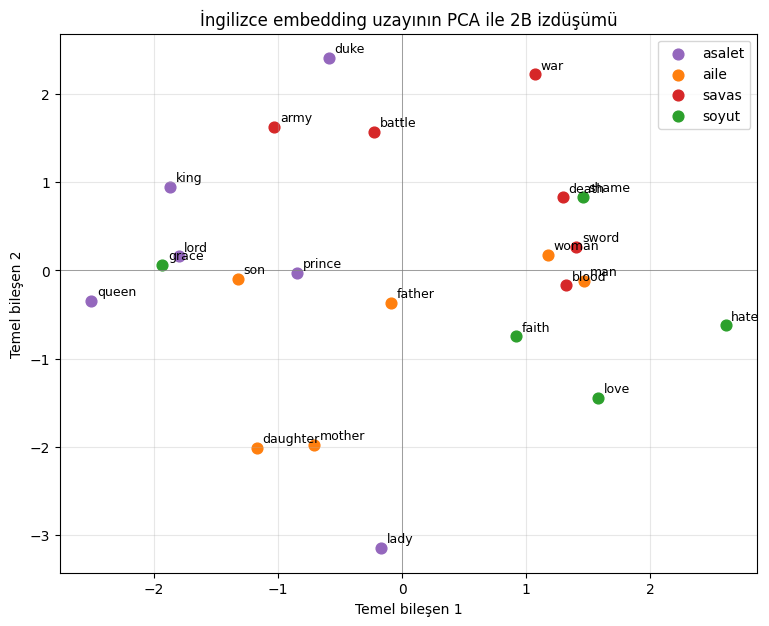

In [9]:
groups = {
    "asalet":  ["king", "queen", "prince", "duke", "lord", "lady"],
    "aile":    ["man", "woman", "father", "mother", "son", "daughter"],
    "savas":   ["sword", "battle", "army", "blood", "death", "war"],
    "soyut":   ["love", "hate", "honor", "faith", "grace", "shame"],
}
colors = {"asalet": "tab:purple", "aile": "tab:orange", "savas": "tab:red", "soyut": "tab:green"}

words_plot, cats_plot = [], []
for cat, ws in groups.items():
    for w in ws:
        if w in word2id_en:
            words_plot.append(w); cats_plot.append(cat)

X = np.array([E_en[word2id_en[w]] for w in words_plot])
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
X2 = Xc @ Vt[:2].T   # ilk 2 temel bileşen üzerine izdüşüm

plt.figure(figsize=(9, 7))
for cat in groups:
    idx = [i for i, c in enumerate(cats_plot) if c == cat]
    plt.scatter(X2[idx, 0], X2[idx, 1], label=cat, color=colors[cat], s=60)
    for i in idx:
        plt.annotate(words_plot[i], (X2[i,0], X2[i,1]), fontsize=9,
                     xytext=(4,4), textcoords="offset points")
plt.axhline(0, color="grey", lw=0.5); plt.axvline(0, color="grey", lw=0.5)
plt.title("İngilizce embedding uzayının PCA ile 2B izdüşümü")
plt.xlabel("Temel bileşen 1"); plt.ylabel("Temel bileşen 2")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("embeddings_pca_en.png", dpi=130, bbox_inches="tight")
plt.show()


## 11) Aynı süreci Türkçe Wikipedia üzerinde tekrarlamak

Aynı `build_vocab` → `make_pairs` → `train_sgns` hattını, gerçek Türkçe Wikipedia cümlelerinden oluşan `tokens_tr` üzerinde çalıştırıyoruz.

Türkçe sözlük boyutu: 4000
Eğitim çifti sayısı : 665,089

Türkçe (Wikipedia) üzerinde eğitim:


  epoch 1/8  ortalama kayıp/çift = 3.1214


  epoch 2/8  ortalama kayıp/çift = 2.6552


  epoch 3/8  ortalama kayıp/çift = 2.5743


  epoch 4/8  ortalama kayıp/çift = 2.4984


  epoch 5/8  ortalama kayıp/çift = 2.4345


  epoch 6/8  ortalama kayıp/çift = 2.3807


  epoch 7/8  ortalama kayıp/çift = 2.3365


  epoch 8/8  ortalama kayıp/çift = 2.3020
Eğitim süresi: 26.8 sn


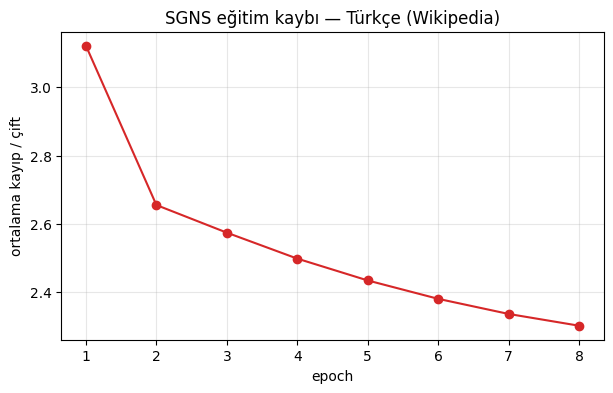

In [10]:
word2id_tr, id2word_tr, freqs_tr = build_vocab(tokens_tr, min_count=5, max_vocab=4000)
centers_tr, contexts_tr = make_pairs(tokens_tr, word2id_tr, window=4)
neg_table_tr = make_neg_table(freqs_tr)

print(f"Türkçe sözlük boyutu: {len(word2id_tr)}")
print(f"Eğitim çifti sayısı : {len(centers_tr):,}")

print("\nTürkçe (Wikipedia) üzerinde eğitim:")
t0 = time.time()
W_in_tr, W_out_tr, losses_tr = train_sgns(centers_tr, contexts_tr, len(word2id_tr),
                                           dim=50, epochs=8, batch_size=1024, lr=0.03,
                                           k_neg=5, neg_table=neg_table_tr)
print(f"Eğitim süresi: {time.time()-t0:.1f} sn")
E_tr = W_in_tr + W_out_tr

plt.figure(figsize=(7,4))
plt.plot(range(1, len(losses_tr)+1), losses_tr, marker="o", color="tab:red")
plt.xlabel("epoch"); plt.ylabel("ortalama kayıp / çift")
plt.title("SGNS eğitim kaybı — Türkçe (Wikipedia)")
plt.grid(alpha=0.3)
plt.show()


In [11]:
for w in ["istanbul", "ordu", "futbol", "kral"]:
    print(f"{w:>10} -> {nearest(w, E_tr, word2id_tr, id2word_tr, topn=7)}")


  istanbul -> [('ankara', 0.655855204556602), ('kadıköy', 0.5506925030617534), ('salonu', 0.5378762522454242), ("park'ta", 0.5226474127513888), ('kuruluş', 0.5093739925925604), ('aydın', 0.507905858625747), ('tiyatrosu', 0.505391236910542)]
      ordu -> [('kızıl', 0.7466285217140916), ('antlaşması', 0.6657326407752132), ('hitler', 0.6639125948505828), ('kuvvetlerinin', 0.663574972492258), ('mareşal', 0.6562444007044995), ('birliklerinin', 0.628999637943935), ('yenilgiye', 0.6210418656339463)]
    futbol -> [("takımı'nın", 0.7648697908392378), ("takımı'nda", 0.6919619200620536), ('kulübüdür', 0.6894622394386055), ('federasyonu', 0.6824583308986548), ('hentbol', 0.6631589403124778), ('milli', 0.6551180007329073), ('litvanya', 0.6423009551174016)]
      kral -> [('karısı', 0.5858620635682268), ('böyle', 0.5568900407268605), ('başlayınca', 0.5540689243065173), ('papa', 0.5508230615103331), ('imparator', 0.5410618840560187), ('ona', 0.5326147358870607), ('canlandırdı', 0.5296516614674041)]

**Gözlem:** `"istanbul"` → `ankara`, `kadıköy`, `aydın` gibi gerçek şehir/ilçe isimleriyle birlikte `salonu`, `tiyatrosu`, `kuruluş` gibi kurum/mekân kelimeleri de karışmış — hâlâ şehir/coğrafya eksenli ama daha gürültülü bir küme. `"ordu"` → `kızıl` (Kızıl Ordu), `hitler`, `mareşal`, `kuvvetlerinin`, `birliklerinin`, `yenilgiye` — belirgin bir askeri/tarih kümesi. `"futbol"` → `...takımı'nın`, `...takımı'nda`, `kulübüdür`, `federasyonu`, `hentbol` — net bir spor kümesi. `"kral"` → `karısı`, `imparator`, `papa` gibi asalet/din-tarih kelimeleriyle birlikte `böyle`, `ona`, `canlandırdı` ("[bu rolü] canlandırdı" — oyunculuk bağlamı) gibi daha genel kelimeler de var. Sadece ~250 bin token'lık bir corpus'la anlamlı ama gürültülü kümelenmeler ortaya çıkıyor — İngilizce'deki (çok daha türdeş bir kaynaktan, tek yazardan gelen) sonuçlara göre daha dağınık olması beklenir.

## 12) Statik embedding'in temel sınırı: çok anlamlılık (polysemy)

Şimdiye kadar gördüğümüz her kelimenin **tek bir** vektörü var — kelime kaç farklı anlamda kullanılırsa kullanılsın. Türkçe'de gerçek çok anlamlı birkaç kelimeyi test edelim: `"kara"` (siyah / kara *[deniz'e karşı]*), `"top"` (top *[oyuncak/silah]* / top *[listenin en üstü, "top 10"]*), `"ocak"` (Ocak ayı / ocak *[soba/mangal]*).

In [12]:
for w in ["kara", "top", "ocak"]:
    print(f"{w:>6} -> {nearest(w, E_tr, word2id_tr, id2word_tr, topn=8)}")


  kara -> [('kuvvetleri', 0.6735555051522106), ('komutanlığı', 0.5697043698996197), ('tarafında', 0.5446044247673401), ('afgan', 0.46257705761055906), ('yoluyla', 0.45524635668711744), ('hava', 0.4511467820157958), ("kuvvetleri'nin", 0.44722955169365003), ('kalır', 0.4443895718213477)]
   top -> [('listesinde', 0.6673740719971955), ('uk', 0.648078429557838), ('country', 0.6006552705074084), ('numaradan', 0.5982461148380132), ('hot', 0.5948744765410788), ('giriş', 0.59359239047955), ('listelerde', 0.5901707368445096), ('girmeyi', 0.5899437910510308)]
  ocak -> [('tarihine', 0.7207211789783685), ('kasım', 0.6750229943191768), ('tarihinde', 0.6375216317916593), ('eylül', 0.6267220099451529), ('temmuz', 0.6220057575822205), ('ayında', 0.6198644714751802), ('şubat', 0.6148036055238854), ('açılmıştır', 0.6128908399450167)]


**Gözlem — ve neden böyle olmak *zorunda*:** Üçünde de komşular büyük ölçüde tek bir anlama kilitlenmiş durumda:

- `"kara"` → `kuvvetleri`, `komutanlığı`, `hava`, `kuvvetleri'nin` — *"kara kuvvetleri / hava kuvvetleri"* (ordu) anlamı baskın; "siyah" (renk) anlamına dair hiçbir iz yok.
- `"top"` → `listesinde`, `uk`, `country`, `numaradan`, `hot`, `listelerde`, `girmeyi` — sadece *müzik listesi ("top 10'a girmek")* anlamı; "top oyuncağı/silahı" anlamı yok.
- `"ocak"` → `tarihine`, `kasım`, `tarihinde`, `eylül`, `temmuz`, `ayında`, `şubat` — sadece *ay ismi* anlamı; "soba/mangal" anlamı yok.

Bu rastlantı değil, **SGNS'in matematiğinin doğrudan sonucu**. Eğitim sırasında `"kara"` kelimesinin TEK BİR vektörü var, ve bu vektör her geçtiği pencerede güncelleniyor — hangi anlamda kullanıldığına bakılmaksızın. Wikipedia'da `"kara"` kelimesi "kara/hava kuvvetleri" anlamında "siyah" anlamına göre çok daha sık geçiyorsa, gradyan güncellemelerinin büyük çoğunluğu da o anlamın bağlamlarından gelir — vektör istatistiksel olarak baskın anlama doğru çekilir, azınlık anlamı sinyal içinde kaybolur.

**Bu, statik (context-free) embedding'lerin temel tavanıdır:** Bir kelimenin kaç anlamı olursa olsun, ona ayrılan tek bir sabit nokta var uzayda. `"O kitabın kara kapağı"` cümlesindeki `"kara"` ile `"Kara kuvvetleri harekete geçti"` cümlesindeki `"kara"`, modele **aynı** vektörle giriyor — oysa insan okuyucu için bu iki cümledeki `"kara"` tamamen farklı şeyler ifade ediyor.

## 13) Sonuç ve ileri bakış

Bu notebook'ta:
- One-hot'un neden bilgisiz olduğunu (kosinüs benzerliği hep 0) gördük.
- Skip-gram + negatif örneklemenin objektifini elle türettik, gradyanları sayısal kontrolle doğruladık.
- Gerçek İngilizce ve Türkçe metin üzerinde sıfırdan (numpy) eğitilen embedding'lerin gerçek anlamsal kümeler (karakterler, şehirler, kurumlar) öğrendiğini, analoji aritmetiğinin ise veri miktarına ne kadar duyarlı olduğunu gördük.
- **Statik embedding'in temel sınırını** somut, ölçülebilir örneklerle gösterdik: bir kelimenin TEK vektörü, o kelimenin TÜM anlamlarının istatistiksel ortalamasıdır — ve baskın anlam, azınlık anlamı(ları) gölgede bırakır.

Bu sınır bizi doğal bir soruya götürüyor: *Bir kelimenin vektörü, içinde geçtiği cümleye göre değişebilse ne olur?* Yani `"kara"` kelimesi `"deniz"` yakınındayken bir vektöre, `"renk"` yakınındayken başka bir vektöre "bükülse"? Bu tam olarak **attention** mekanizmasının yaptığı şey — her token için, o anki bağlamına bakarak *anlık* (contextual) bir temsil hesaplamak. `03_self_attention`'da bunu, Query/Key/Value ile matematiksel olarak nasıl yaptığını inceleyeceğiz.

## Egzersizler

Bu bölümdeki soruların çözümü verilmiyor — kendi başına denemen bekleniyor. Yeni hücreler ekleyerek çalış.

1. `train_sgns`'i `dim = 10, 50, 100, 200` için ayrı ayrı çalıştır (İngilizce corpus üzerinde). Her boyut için `"king"`in en yakın 6 komşusunu yazdır. Boyut arttıkça komşuluk kalitesi nasıl değişiyor? Çok küçük boyutta (örn. 10) ne kayboluyor, çok büyük boyutta (örn. 200) ne oluyor (ipucu: eğitim çifti sayımız sabit, parametre sayısı ise boyutla katlanarak artıyor)?
2. `make_pairs`'teki `window` parametresini `1` ve `10` için ayrı ayrı dene. `window=1` ile eğitilen embedding'de `"king"`in komşuları ile `window=10` ile eğitilende gördüğün komşular arasında ne tür bir fark var (ipucu: dar pencere sözdizimsel/yakın-komşuluk ilişkilerini, geniş pencere daha "konusal" ilişkileri yakalamaya meyilli olur)?
3. Bu notebook'ta **Skip-gram**'ı kullandık (merkezden bağlamı tahmin et). Word2Vec'in ikinci mimarisi **CBOW** (Continuous Bag-of-Words) ise bunun tersini yapar: birden fazla bağlam kelimesinin (örn. ortalamasının) vektöründen merkez kelimeyi tahmin eder. Bölüm 3'teki türetmeye benzer şekilde, CBOW için negatif örnekleme kaybını ve $v_c$ (artık bağlam ortalaması), $v_o$ (artık tahmin edilen merkez) ile negatiflere göre gradyanlarını elle türet, sonra `train_cbow` adında yeni bir fonksiyon olarak kodla. İki mimarinin öğrendiği embedding'leri aynı kelimeler için karşılaştır.
4. `data/corpus_turkce.txt` dosyasına, `"kara"` kelimesinin SADECE "siyah" (renk) anlamında geçtiği 15-20 yeni gerçek cümle ekle (örn. haber cümleleri, ürün açıklamaları). Embedding'i yeniden eğit ve `"kara"`nın en yakın komşularının değişip değişmediğine bak. Bölüm 12'deki matematiksel açıklamayla tutarlı mı (ipucu: eklediğin cümle sayısının, kelimenin toplam geçiş sayısına oranını hesapla — bu oran gerçekten "renk" anlamını baskın anlam yapmaya yetiyor mu)?
5. **(Bonus — internet gerektirir)** `pip install gensim` kurup gerçek `gensim.models.Word2Vec`'i aynı `data/corpus_english.txt` üzerinde (benzer `vector_size`, `window`, `negative` parametreleriyle) eğit. `"king - man + woman"` analojisini gensim'in optimize edilmiş (ve muhtemelen daha uzun eğitilmiş) implementasyonuyla tekrar dene — sonuç bizim sıfırdan yazdığımız `train_sgns`'ten farklı mı? Fark neden kaynaklanıyor olabilir?

In [13]:
print("==== Egzersiz 1 ====")


==== Egzersiz 1 ====


In [14]:
print("==== Egzersiz 2 ====")


==== Egzersiz 2 ====


In [15]:
print("==== Egzersiz 3 ====")


==== Egzersiz 3 ====


In [16]:
print("==== Egzersiz 4 ====")


==== Egzersiz 4 ====


In [17]:
print("==== Egzersiz 5 (Bonus - internet gerektirir) ====")


==== Egzersiz 5 (Bonus - internet gerektirir) ====


## Kaynaklar

- Mikolov, T., Chen, K., Corrado, G., Dean, J. (2013). *Efficient Estimation of Word Representations in Vector Space.* [arXiv:1301.3781](https://arxiv.org/abs/1301.3781) — Skip-gram ve CBOW mimarilerinin orijinal makalesi.
- Mikolov, T., Sutskever, I., Chen, K., Corrado, G., Dean, J. (2013). *Distributed Representations of Words and Phrases and their Compositionality.* [arXiv:1310.4546](https://arxiv.org/abs/1310.4546) — Negatif örnekleme ve alt örnekleme (subsampling) tekniklerinin tanıtıldığı makale.
- Pennington, J., Socher, R., Manning, C. (2014). *GloVe: Global Vectors for Word Representation.* [ACL Anthology D14-1162](https://aclanthology.org/D14-1162/) — Word2Vec'e alternatif, sayım-tabanlı bir embedding yöntemi (karşılaştırma için).
- Firth, J.R. (1957). *A Synopsis of Linguistic Theory, 1930-1955.* — "Dağılımsal hipotez"in klasik formülasyonu; bkz. [Quote Investigator'ın atıf incelemesi](https://quoteinvestigator.com/2022/09/18/word-company/).
- Alammar, J. *The Illustrated Word2vec.* [jalammar.github.io](https://jalammar.github.io/illustrated-word2vec/) — Skip-gram ve negatif örneklemenin görsel anlatımı.
- Veri — İngilizce: *Tiny Shakespeare*, [karpathy/char-rnn](https://github.com/karpathy/char-rnn) deposu, `data/tinyshakespeare/input.txt`.
- Veri — Türkçe: *Turkish-Wiki-NER-Dataset*, [turkish-nlp-suite/Turkish-Wiki-NER-Dataset](https://github.com/turkish-nlp-suite/Turkish-Wiki-NER-Dataset) (CC-BY-SA-4.0), sadece düz cümleler kullanıldı, NER etiketleri atıldı.